In [1]:
import os
path_to_add = "/global/software/sl-7.x86_64/modules/tools/texlive/2016/bin/x86_64-linux"
os.environ["PATH"] = path_to_add + os.pathsep + os.environ["PATH"]

import math
import numpy as np
import scipy.special as spf
import scipy.interpolate as interp
import time
import quaternionic as qnc 
import h5py
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as clr
plt.rc('text', usetex=True)


import vsdm
from vsdm.units import *
from vsdm.utilities import *


diffM, diffV = vsdm.testG_lm(5, -3, printout=False)
if np.abs(diffV) < 1e-14:
    print("testing 'spherical' and WignerG: PASS")
else:
    print("testing 'spherical' and WignerG: FAIL")
    print("check the version number for 'spherical', and run testD_lm()")
print("vsdm", vsdm.__version__)

deg = np.pi/180
unisize = 3.5

from scipy import optimize

testing 'spherical' and WignerG: PASS
vsdm 0.4.4
earthspeed 1.2


In [2]:
"""define functions and global variables"""

def getQ(theta, phi):
    # finds the rotation that moves a 'z hat' unit vector to point towards (theta, phi)
    axisphi = phi + np.pi/2 #stationary under R
    axR = theta/2 
    qr = np.cos(axR)
    qi = np.sin(axR) * np.cos(axisphi)
    qj = np.sin(axR) * np.sin(axisphi)
    qk = 0. 
    return qnc.array(qr, qi, qj, qk)

def rotateBy(qR, v):
    # rotate a vector v (or array of vectors) by rotation operator qR
    return qR * v / qR

def nhat(theta, phi):
    nx = np.sin(theta) * np.cos(phi) 
    ny = np.sin(theta) * np.sin(phi) 
    nz = np.cos(theta) 
    return np.array([nx, ny, nz])

def rotationQ(theta, phi, alpha):
    "Encodes a rotation by angle 'alpha' about the (theta,phi) unit vector."
    nx,ny,nz = nhat(theta, phi)
    axR = alpha/2 
    cosah = np.cos(alpha/2) 
    sinah = np.sin(alpha/2) 
    return qnc.array(cosah, sinah*nx, sinah*ny, sinah*nz)

def qfunc(qr, vec3d):
    return qnc.array(qr, vec3d[0], vec3d[1], vec3d[2])

def makeCone(theta_north, phi_north, phase, thetaN=(42*deg), dt_h=0.2):
    """Returns the Earth velocity unit vector vE as a function of time.
    
    theta_north, phi_north: a 2d unit vector specifying the location of the north pole 
        (in the crystal coordinate frame, where theta=0 is the "b=z" direction)
    phase: shifts the "t=0" starting position of vE
    thetaN: the angle between the DM wind and the north pole (radians)
    dt_h: the time step to use, in sidereal hours (24h = 360 deg)

    returns lists of tH,theta_E,phi_E, with angles in radians and times in sidereal hours
    """
    # north pole vector:
    northvec = nhat(theta_north, phi_north)
    # Step 1: find a starting position for vE, rotating "northvec" by thetaN about any orthogonal vector.
    eps = 0.005
    # default: define the rotation axis as orthogonal to "x":
    axis_init = np.cross(northvec, np.array([1, 0, 0]))
    # if northvec is colinear with "x", use the "y" axis instead:
    if np.linalg.norm(axis_init) < eps:
        axis_init = np.cross(northvec, np.array([0, 1, 0]))
    # rotate about axis_init by angle thetaN:
    one,theta_ai,phi_ai = cart_to_sph(axis_init)
    Q_init = rotationQ(theta_ai, phi_ai, thetaN)
    qnorth = qfunc(0., northvec)
    vE_init = rotateBy(Q_init, qnorth)

    Q_phase = rotationQ(theta_north, phi_north, phase)
    vE_0 = rotateBy(Q_phase, vE_init)

    # Step 2: rotate vE_0 about the north pole
    lenT = int(24.0 / dt_h) + 1 # include 24.0h at the end
    sid_times = [j*dt_h for j in range(lenT)]
    thetaE = []
    phiE = []
    for t in sid_times: 
        alpha = t/24 * 2*np.pi # rotation angle 
        Q_t = rotationQ(theta_north, phi_north, alpha) # rotation operator 
        qE_t = rotateBy(Q_t, vE_0) # rotated vector (as quaterion) 
        vE_t = qE_t.imag # convert back to 3d vector 
        one,theta,phi = cart_to_sph(vE_t) # convert to spherical coordinate
        thetaE += [theta]
        phiE += [phi]
    return np.array(sid_times), np.array(thetaE), np.array(phiE)

### TRANS-STILBENE FORM FACTORS: s1, s2, s5, s8

"""Definition of the Q and V basis functions:"""
# (these should not be changed, without also changing McalK)

QMAX = 24*keV # Global value for q0=qMax for wavelets
Qbasis = dict(u0=QMAX, type='wavelet', uMax=QMAX)

VMAX = 820.*km_s # Global value for v0=vMax for wavelets
Vbasis = dict(u0=VMAX, type='wavelet', uMax=VMAX)

DeltaE = {}
DeltaE['s1'] = 4.24*eV
DeltaE['s2'] = 4.788*eV
DeltaE['s5'] = 5.791*eV
DeltaE['s8'] = 6.439*eV


"""When creating tstilbene_mK.hdf5, this format was used for the model labels:"""

ellMax = 24
nvMax = 511
nqMax = 1023
lmod = 2
mXlist = [2, 3, 5, 10, 20, 30, 50, 100]

def h5modelname(sI, dmModel, mX_MeV_float=0):
    """Define a consistent style for labeling McalI[dmModel] in this hdf5.

    returns: ('sI') + '/' + ('fdm') + '/' + ('mX_MeV')
        fdm = dmModel['fdm']
        mX_MeV = dmModel['mX']/MeV
    mX_MeV_float controls how many decimal points to include in the
        string version of mX/MeV
    """
    fdm = dmModel['fdm']
    mX_MeV = dmModel['mX'] / MeV
    if mX_MeV_float==0:
        mX_str = str(int(mX_MeV))
    elif mX_MeV_float==1:
        mX_str = '{:.1f}'.format(mX_MeV)
    elif mX_MeV_float==2:
        mX_str = '{:.12}'.format(mX_MeV)
    elif mX_MeV_float==3:
        mX_str = '{:.3f}'.format(mX_MeV)
    mIstr = '{}/{}/{}'.format(sI, fdm, mX_str)
    return mIstr

## Routine Number One: Tabulate and Save $R(\theta, \phi)$

This part takes about two minutes to evaluate `wG`.

In [3]:
### This function only needs to be run once for each (n,mX) model.
"""Calculate WignerG matrix"""
rotationlist = []
rotationarray = []
thetaphilist = []

for theta in range(0, 181, 2):
    rrow = []
    for phi in range(0, 361, 2):
        # for WignerG, want to apply the inverse of getQ.
        # getQ applied to vE moves vE from the z axis to the position (theta, phi). 
        # 1/getQ applied to the crystal does the same thing, 
        #     with vE -> (theta, phi) in the frame of the crystal.
        q = 1/getQ(theta * np.pi/180, phi * np.pi/180) 
        rrow += [q] 
        rotationlist += [q] 
        thetaphilist += [(theta, phi)]
    rotationarray += [rrow]

rotationarray = np.array(rotationarray)

"""Calculate the Wigner G matrix for each rotation (takes ~2 minutes)"""
wG = vsdm.WignerG(ellMax, rotations=rotationlist, lmod=2)


thetas = [theta for theta in range(0, 181, 2)]
phis = [phi for phi in range(0, 361, 2)]
thetaphi_size = (np.shape(rotationarray)[0], np.shape(rotationarray)[1])

data_dir = os.getcwd() + '/data/'
np.save(data_dir+'thetas.npy', thetas)
np.save(data_dir+'phis.npy', phis)
# Assuming the same grid of theta,phi for all DM models. 
# If not, for some reason, add an identifying modelstring to file names above. 


def writeRinterpolated(n, mX, modelstring, sI='tot'):
    """Calculates WignerG and McalK, saves R(theta, phi) to file.
    
       n = 0,2: heavy/light mediator
       mX: (integer) DM mass in MeV. Choose from list
       modelstring: saves files to data/{modelstring}_{etc}

       Assumes the mK.hdf5 file is saved to 'data/tstilbene_mK.hdf5'
    """
    
    assert (n in [0,2]), "n must be 0 or 2"
    assert (mX in mXlist), "only includes mX = 2,3,5,10,20,30,50,100"
    assert (sI in ['s1', 's2', 's5', 's8', 'tot']), "only includes s1,s2,s5,s8"

    if sI=='tot':
        sIlist = ['s1', 's2', 's5', 's8']
    else: 
        sIlist = [sI]

    """Import from HDF5"""
    rates = {}
    with h5py.File('data/tstilbene_mK.hdf5','r') as hdf5:
        for sI in sIlist:
            dmModel = dict(mX=mX*MeV, fdm=n, mSM=mElec, DeltaE=DeltaE[sI])
            thislabel = h5modelname(sI, dmModel, mX_MeV_float=0)
            dataK = hdf5[thislabel+'/mcalK'][:]
            newK = vsdm.McalK(ellMax, lmod=2)
            newK.vecK = dataK
            rates[sI] = newK

    """Combinations of s1, s2, s5, s8:"""
    if sI=='tot':
        vecK_s1 = rates['s1'].vecK
        vecK_tot = np.copy(vecK_s1)
        for sI in ['s2', 's5', 's8']:
            vecK_tot += vecK_other
        newK = vsdm.McalK(ellMax, lmod=2)
        newK.vecK = vecK_tot
        rates['tot'] = newK
    else:
        rates['tot'] = rates[sI]

    # Only using rates['tot'] going forwards. 


    """Rate calculation, including isotropic norm <R>:"""
    rate_R = rates['tot'].mu_R(wG).reshape(thetaphi_size) # rate, sans exposure factor 'mu0'
    rate_K000 = rates['tot'].vecK[0] # the ell=0 component of vecK is the angular average

    """Save R(theta,phi), etc to binary files:"""
    data_dir = os.getcwd() + '/data/'
    np.save(data_dir+modelstring+'_rateArray.npy', rate_R)
    np.save(data_dir+modelstring+'_K000.npy', np.array(rate_K000)) # convenient integer K_000
    

    

### Example: Saving all relevant $R(\theta, \phi)$ arrays to `.npy`
It takes a couple minutes to save all of the $R(\theta, \phi)$ arrays for every DM model $(n, m_\chi)$.  

In [5]:
for n in [0, 2]:
    for mX in [2, 3, 5, 10, 20, 30, 50, 100]:
        modname = 'tot_n{}_mX{}'.format(n, mX)
        writeRinterpolated(n, mX, modname, sI='tot')

In [6]:
for n in [0, 2]:
    for mX in [2, 3, 5, 10, 20, 30, 50, 100]:
        modname = 's1_n{}_mX{}'.format(n, mX)
        writeRinterpolated(n, mX, modname, sI='s1')

## Routine Number Two: Get $R(t)$ from $R(\theta, \phi)$

Converts a previously tabulated $R(\theta, \phi)$ for a specific DM model into an interpolating function, which is then used to generate $R(t)$ for any detector orientation. 

In [7]:
class simpleRate():
    def __init__(self, modelstring, sigma0_cm2=1e-38, mass_kg=1.):
        # read data from npy:
        data_dir = os.getcwd() + '/data/'
        self.thetas = np.load(data_dir+'thetas.npy') # in degrees
        self.phis = np.load(data_dir+'phis.npy') # in degrees
        self.K000 = np.load(data_dir+modelstring+'_K000.npy')
        self.rate_array = np.load(data_dir+modelstring+'_rateArray.npy')

        our_rhoX = 0.4 #GeV/cm^3
        """Exposure Factor:
            exp_kgyr: total exposure time*mass. 
                To get a rate in Hz, choose exp_kgyr = (mass/kg) * (1/3.15e7) 
        """
        exp_time_yr = 1./vsdm.SECONDS_PER_YEAR # for rate in Hertz. 
        self.k0 = vsdm.g_k0(exp_kgyr=mass_kg*exp_time_yr, sigma0_cm2=sigma0_cm2, rhoX_GeVcm3=our_rhoX, 
                            mCell_g=4*(180.250), # molar mass of TSB crystal unit cell 
                            v0=Vbasis['u0'], q0=Qbasis['u0']) # global constants from mK.hdf5

        self.isoR_Hz = self.K000 * self.k0 # isotropic average rate <R> in Hz
        """Define the interpolating function R(theta, phi):"""
        data = np.array([[self.rate_array[ix, iy]
                          for iy in range(len(phis))] 
                         for ix in range(len(thetas))])
        self.rate_intp_deg = interp.RegularGridInterpolator((thetas, phis), data)  # in degrees

    def dailyModMe(self, theta_north, phi_north, phase, thetaN=(42*deg), dt_h=0.25):
        """Returns the rate as a function of time for a daily modulation analysis.
    
        rate_intp: interpolating function R(theta, phi), for theta and phi in degrees 
        theta_north, phi_north, phase: orientation of the sample
        thetaN: angle between "north" and the DM wind. Varies annually
        dt_h: time step size, in sidereal hours
    
        returns the lists tH,R(tH) 
        """
        t_h, thetaE, phiE = makeCone(theta_north, phi_north, phase, thetaN=thetaN, dt_h=dt_h)
        rate_Hz = self.k0*self.rate_intp_deg([[thetaE[j]/deg, phiE[j]/deg] for j in range(len(t_h))])
        return t_h, rate_Hz
        

# Examples

In [8]:
# Example 1: Isotropic Average Rates

"""exposure factor for 1 kg of trans-stilbene, for 1 second"""
k0 = vsdm.g_k0(exp_kgyr=1./SECONDS_PER_YEAR, mCell_g=721.0, 
               sigma0_cm2=1e-38, rhoX_GeVcm3=0.4, 
               v0=Vbasis['u0'], q0=Qbasis['u0'])

"""angular averages <R> for each model:"""
print('rates in Hz:')
data_dir = os.getcwd() + '/data/'
for n in [0,2]: 
    for mX in [2, 3, 5, 10, 20]:
        modname = 's1_n{}_mX{}'.format(n, mX)
        rate_K000 = np.load(data_dir+modname+'_K000.npy')
        K000 = rate_K000 
        print('{:>11}: <R> = {:.4e} Hz'.format(modname, K000*k0))

rates in Hz:
  s1_n0_mX2: <R> = 8.1525e-06 Hz
  s1_n0_mX3: <R> = 3.7290e-05 Hz
  s1_n0_mX5: <R> = 7.1227e-05 Hz
 s1_n0_mX10: <R> = 6.9129e-05 Hz
 s1_n0_mX20: <R> = 4.3860e-05 Hz
  s1_n2_mX2: <R> = 4.9563e-06 Hz
  s1_n2_mX3: <R> = 1.4796e-05 Hz
  s1_n2_mX5: <R> = 2.1463e-05 Hz
 s1_n2_mX10: <R> = 1.7583e-05 Hz
 s1_n2_mX20: <R> = 1.0672e-05 Hz


In [9]:
# Example 2: Using simpleRate()

n = 2
mX = 5 # MeV
dm_model = simpleRate('s1_n{}_mX{}'.format(n, mX), mass_kg=10.)
print('<R> = {:.5e} Hz'.format(dm_model.isoR_Hz))

theta_north = 35*deg
phi_north = 245*deg
phase = 0*deg
thetaN = 42*deg # close to the January average
t_h, Ra_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)

theta_north = 35*deg
phi_north = 245*deg
phase = 180*deg
thetaN = 42*deg # close to the January average
t_h, Rb_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)

<R> = 2.14629e-04 Hz


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_2838/3990929019.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


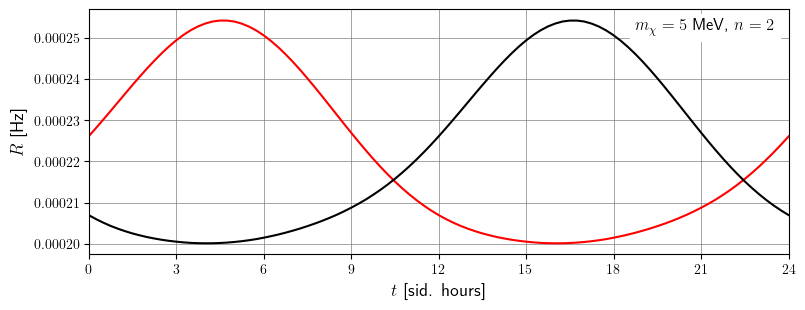

In [10]:
"""Plot R(t):"""

fig = plt.figure(figsize=[2.0*unisize,unisize])
ax2 = fig.add_axes([0,0,1,0.7], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R$ [Hz]', fontsize=13, usetex=True)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)


ax2.plot(t_h, Ra_Hz, color='red')
ax2.plot(t_h, Rb_Hz, color='black')
# mX, n label:
ax2.text(0.98, 0.96, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='right',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)


# plt.savefig('out/modRate_mX{}_n{}_eg.png'.format(mX, n), 
#             format="png", dpi=600, bbox_inches='tight')

fig.show()